In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline


In [37]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sktime.datasets import load_airline
from adaptiveforecast.forecaster import AdaptiveForecaster
from adaptiveforecast.ensembleforecaster import EnsembleManager

In [3]:
y = load_airline()

In [47]:
model_results={}
algorithms = ['naive','exp_smoothing','stats_arima', 'exp_smoothing','ets','tbats','prophet']
for algo in algorithms:
    algo_forecaster = AdaptiveForecaster(
            algorithm=algo,
            seasonal_period=12,
            fh=12,
            cv_strategy='expanding',
            cv_initial_window=80,
            cv_step_length=3,
            metric='mape',
            n_jobs=1,
            verbose=1
        )
    

    # Initialize and fit the forecaster first
    train_y, test_y = algo_forecaster.split_data(y)
    algo_forecaster.fit(train_y)

# Get future forecasts and all results
    results = algo_forecaster.forecast_future(y, future_horizon=12)
    model_results[algo] = results

ensemble_manager = EnsembleManager(model_results)

# Get ensemble forecasts with similar structure to individual forecasts
ensemble_results = ensemble_manager.forecast_future(y, future_horizon=12)

# Update model_results with ensemble results
model_results.update(ensemble_results)


Fitting naive forecaster with expanding cross-validation...
Fitting 8 folds for each of 144 candidates, totalling 1152 fits


/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/naive.py:184: UserWarning: For the `drift` strategy, the `sp` value will be ignored.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/naive.py:184: UserWarning: For the `drift` strategy, the `sp` value will be ignored.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/naive.py:184: UserWarning: For the `drift` strategy, the `sp` value will be ig

Making predictions...

Test Performance Metrics:
------------------------------
RMSE: 122.6324
MAPE: 0.2763
MAE: 109.9138
MSE: 15038.7033
Refitting naive on full dataset with best parameters...
Generating future predictions for 12 periods...
Fitting exp_smoothing forecaster with expanding cross-validation...
Fitting 8 folds for each of 144 candidates, totalling 1152 fits
Making predictions...

Test Performance Metrics:
------------------------------
RMSE: 87.5385
MAPE: 0.1929
MAE: 77.8791
MSE: 7662.9885
Refitting exp_smoothing on full dataset with best parameters...
Generating future predictions for 12 periods...
Fitting stats_arima forecaster with expanding cross-validation...
Fitting 8 folds for each of 32 candidates, totalling 256 fits


/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsmodels/tsa/holtwinters/model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warning

Making predictions...

Test Performance Metrics:
------------------------------
RMSE: 58.8806
MAPE: 0.1320
MAE: 53.0846
MSE: 3466.9294
Refitting stats_arima on full dataset with best parameters...
Generating future predictions for 12 periods...
Fitting exp_smoothing forecaster with expanding cross-validation...
Fitting 8 folds for each of 144 candidates, totalling 1152 fits


...

/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/naive.py:184: UserWarning: For the `drift` strategy, the `sp` value will be ignored.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings

Generating Auto Ensemble forecasts...


23:03:54 - cmdstanpy - INFO - Chain [1] start processing
23:03:54 - cmdstanpy - INFO - Chain [1] done processing
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/naive.py:184: UserWarning: For the `drift` strategy, the `sp` value will be ignored.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsmodels/tsa/holtwinters/model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-

Generating Online Ensemble forecasts...


/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/base/_base.py:2175: UserWarning: NotImplementedWarning: NaiveForecaster does not have a custom `update` method implemented. NaiveForecaster will be refit each time `update` is called with update_params=True. To refit less often, use the wrappers in the forecasting.stream module, e.g., UpdateEvery.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/naive.py:184: UserWarning: For the `drift` strategy, the `sp` value will be ignored.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/base/_base.py:2175: UserWarning: NotImplementedWarning: ExponentialSmoothing does not have a custom `update` method implemented. ExponentialSmoothing will be refit each time `update` is called with update_params=True. To refit less often, use the wrappers in the forecas

In [50]:
model_results['auto_ensemble']['model_weights']

{'naive': 0.0054824706993604495,
 'exp_smoothing': 0.004649144380936123,
 'stats_arima': 0.02681649793118053,
 'ets': 0.009498917250569198,
 'tbats': 0.1220218273405969,
 'prophet': 0.8315311423973568}

In [51]:
model_results['auto_ensemble']['metrics']

{'rmse': 19.517552608914247,
 'mse': 380.9348598417354,
 'mae': 15.119106083883908,
 'mape': 0.03438370593088907}

In [ ]:
from sktime.forecasting.compose import AutoEnsembleForecaster
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.datasets import load_airline
from sktime.split import ExpandingWindowSplitter,temporal_train_test_split
y = load_airline()

y_train, y_test = temporal_train_test_split(y=y, test_size=12)

forecasters = [
    ("naive", model_results['naive']['best_forecaster']),
    ("exp_smoothing", model_results['exp_smoothing']['best_forecaster']),
    ("stats_arima", model_results['stats_arima']['best_forecaster']),
    ("ets", model_results['ets']['best_forecaster']),
    ("tbats", model_results['tbats']['best_forecaster']),
    ("prophet", model_results['prophet']['best_forecaster']),

]
auto_ensemble_forecaster = AutoEnsembleForecaster(forecasters=forecasters)
auto_ensemble_forecaster.fit(y=y_train)
y_pred = auto_ensemble_forecaster.predict(fh=[1,2,3,4,5,6,7,8,9,10,11,12])

from sktime.forecasting.online_learning import (
    NormalHedgeEnsemble,
    OnlineEnsembleForecaster,
)
from sktime.utils.plotting import plot_series
y_train, y_test = temporal_train_test_split(y=y, test_size=12)
hedge_expert = NormalHedgeEnsemble(n_estimators=6, loss_func=mean_absolute_percentage_error)

forecasters = OnlineEnsembleForecaster([
    ("naive", model_results['naive']['best_forecaster']),
    ("exp_smoothing", model_results['exp_smoothing']['best_forecaster']),
    ("stats_arima", model_results['stats_arima']['best_forecaster']),
    ("ets", model_results['ets']['best_forecaster']),
    ("tbats", model_results['tbats']['best_forecaster']),
    ("prophet", model_results['prophet']['best_forecaster']),

],ensemble_algorithm=hedge_expert)
forecasters.fit(y=y_train)
y_pred = forecasters.update_predict_single(y_test, fh=[1,2,3,4,5,6,7,8,9,10,11,12])
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
mean_absolute_percentage_error(y_test, y_pred, symmetric=False)

/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/naive.py:184: UserWarning: For the `drift` strategy, the `sp` value will be ignored.
  warn(
22:23:07 - cmdstanpy - INFO - Chain [1] start processing
22:23:08 - cmdstanpy - INFO - Chain [1] done processing
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/naive.py:184: UserWarning: For the `drift` strategy, the `sp` value will be ignored.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/si

In [34]:
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
mean_absolute_percentage_error(y_test, y_pred, symmetric=False)

0.04690822692625082

/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/sktime/forecasting/naive.py:184: UserWarning: For the `drift` strategy, the `sp` value will be ignored.
  warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/.venv/lib/python3.9/site-packages/statsforecast/arima.py:479: UserWarning: possible convergence problem: minimize gave code 2]
  warnings

0.10943427870729627

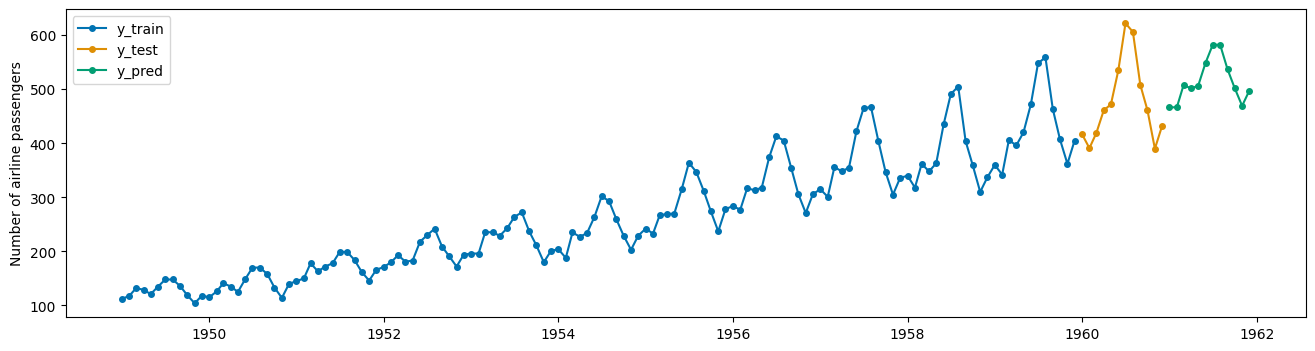

In [35]:
from sktime.forecasting.online_learning import (
    NormalHedgeEnsemble,
    OnlineEnsembleForecaster,
)
from sktime.utils.plotting import plot_series
y_train, y_test = temporal_train_test_split(y=y, test_size=12)
hedge_expert = NormalHedgeEnsemble(n_estimators=6, loss_func=mean_absolute_percentage_error)

forecasters = OnlineEnsembleForecaster([
    ("naive", model_results['naive']['best_forecaster']),
    ("exp_smoothing", model_results['exp_smoothing']['best_forecaster']),
    ("stats_arima", model_results['stats_arima']['best_forecaster']),
    ("ets", model_results['ets']['best_forecaster']),
    ("tbats", model_results['tbats']['best_forecaster']),
    ("prophet", model_results['prophet']['best_forecaster']),

],ensemble_algorithm=hedge_expert)
forecasters.fit(y=y_train)
y_pred = forecasters.update_predict_single(y_test, fh=[1,2,3,4,5,6,7,8,9,10,11,12])
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
mean_absolute_percentage_error(y_test, y_pred, symmetric=False)




In [23]:
forecasters.

array([0., 1.])

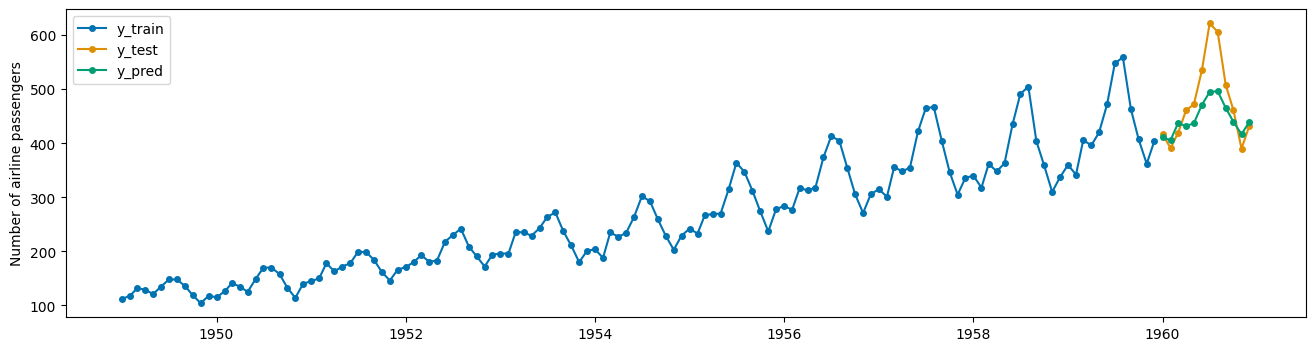

In [12]:

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"]);

In [6]:
y_pred

1961-01    438.453040
1961-02    429.947256
1961-03    465.845412
1961-04    462.890186
1961-05    469.071187
1961-06    510.846835
1961-07    541.409467
1961-08    543.199321
1961-09    500.705285
1961-10    467.166407
1961-11    437.763081
1961-12    465.026775
Freq: M, Name: Number of airline passengers, dtype: float64

In [52]:
model_results['auto_ensemble']['future_predictions']

1961-01    440.641157
1961-02    443.555782
1961-03    464.820447
1961-04    471.268629
1961-05    480.045881
1961-06    518.606932
1961-07    563.639250
1961-08    564.827211
1961-09    509.586228
1961-10    459.882703
1961-11    438.891006
1961-12    456.126043
Freq: M, Name: Number of airline passengers, dtype: float64

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adaptiveforecast.tscleaner import (
    create_cleaning_pipeline, 
    detect_and_handle_outliers,
    fix_index_and_frequency,
    handle_extreme_values,
    remove_missing_values,
    create_report
)

# ========================
# Create sample time series data with various issues
# ========================

# Create date range with missing dates
dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
# Remove some dates to create gaps
dates = dates.drop(dates[10:15].union(dates[50:52]))

# Create noisy values with trend and seasonality
values = 10 + 0.05 * np.arange(len(dates))  # Linear trend
values += 5 * np.sin(np.linspace(0, 4*np.pi, len(dates)))  # Seasonality
values += np.random.normal(0, 1, len(dates))  # Random noise

# Create outliers
outlier_indices = [5, 30, 70]
for idx in outlier_indices:
    if idx < len(values):
        values[idx] = values[idx] + 20 if idx % 2 == 0 else values[idx] - 15

# Create missing values
missing_indices = [25, 45, 65, 85]
for idx in missing_indices:
    if idx < len(values):
        values[idx] = np.nan

# Create a second column with different characteristics
values2 = np.zeros(len(dates))  # Constant column (should be removed)

# Create a third column with extreme values
values3 = values.copy() + np.random.normal(0, 2, len(dates))
extreme_indices = [8, 40, 75]
for idx in extreme_indices:
    if idx < len(values3):
        values3[idx] = values3[idx] * 10

# Create DataFrame
df = pd.DataFrame({
    'main_series': values,
    'constant_series': values2,
    'extreme_series': values3
}, index=dates)

# Create duplicate indices (add some days twice)
additional_data = pd.DataFrame({
    'main_series': [values[0] + 1, values[20] + 1],
    'constant_series': [0, 0],
    'extreme_series': [values3[0] + 1, values3[20] + 1]
}, index=[dates[0], dates[20]])

# Concatenate to create duplicates
df = pd.concat([df, additional_data])

# ========================
# Example 1: Using the complete cleaning pipeline
# ========================
print("="*50)
print("Example 1: Using the complete cleaning pipeline")

# Create a cleaning pipeline with default settings
pipeline = create_cleaning_pipeline(
    fix_index=True,
    handle_duplicates=True,
    remove_missing=True,
    handle_outliers=True,
    handle_extremes=True,
    remove_constants=True,
    # Customizing some parameters
    duplicate_params={'method': 'mean'},
    missing_params={'method': 'cubic', 'limit': 5},
    outlier_params={'method': 'hampel', 'window_length': 5, 'n_sigma': 3.0},
    extreme_params={'lower_quantile': 0.001, 'upper_quantile': 0.999, 'method': 'clip'}
)

# Apply the cleaning pipeline
cleaned_df = pipeline.fit_transform(df)

# Generate and print a report
report = create_report(df, cleaned_df, include_plots=True)

print(f"Original shape: {report['original_shape']}")
print(f"Cleaned shape: {report['cleaned_shape']}")
print(f"Missing values before: {report['missing_values_before']}")
print(f"Missing values after: {report['missing_values_after']}")
print(f"Duplicate indices before: {report['duplicates_before']}")
print(f"Duplicate indices after: {report['duplicates_after']}")
print(f"Columns removed: {report['columns_removed']}")

# Display plots if available
if 'plots' in report:
    fig_time_series = report['plots']['time_series']
    fig_time_series.show()



Example 1: Using the complete cleaning pipeline


/home/yaeg/Documents/projects/packages/Adaptive_forecast/adaptiveforecast/tscleaner.py:279: UserWarning: Could not infer frequency from data. Using 'D' (daily) as default frequency.
  warnings.warn(
/home/yaeg/Documents/projects/packages/Adaptive_forecast/adaptiveforecast/tscleaner.py:382: UserWarning: Removing 1 constant or near-constant columns
  warnings.warn(


Original shape: (95, 3)
Cleaned shape: (100, 2)
Missing values before: {'main_series': 4, 'constant_series': 0, 'extreme_series': 4}
Missing values after: {'main_series': 0, 'extreme_series': 0}
Duplicate indices before: 2
Duplicate indices after: 0
Columns removed: ['constant_series']


/tmp/ipykernel_8324/3805422847.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_time_series.show()


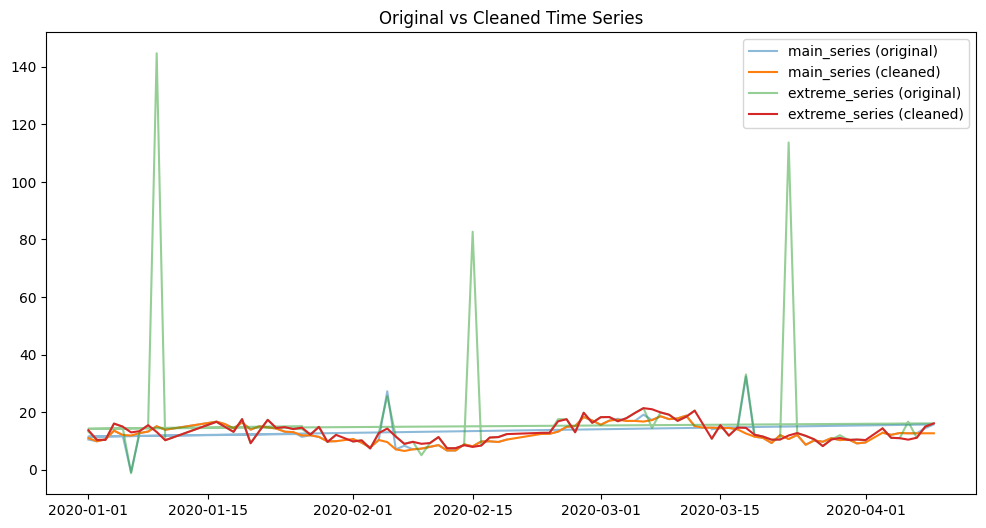

In [56]:
fig_time_series

In [60]:
pipeline.cleaning_steps

[(<function adaptiveforecast.tscleaner.handle_duplicate_indices(X: pandas.core.frame.DataFrame, method: str = 'mean') -> pandas.core.frame.DataFrame>,
  {'method': 'mean'}),
 (<function adaptiveforecast.tscleaner.fix_index_and_frequency(X: pandas.core.frame.DataFrame, freq: Optional[str] = None, start_date: Optional[str] = None, end_date: Optional[str] = None, fill_missing: bool = True) -> pandas.core.frame.DataFrame>,
  {}),
 (<function adaptiveforecast.tscleaner.remove_constant_columns(X: pandas.core.frame.DataFrame, threshold: float = 0.0) -> pandas.core.frame.DataFrame>,
  {}),
 (<function adaptiveforecast.tscleaner.handle_extreme_values(X: pandas.core.frame.DataFrame, lower_quantile: float = 0.001, upper_quantile: float = 0.999, method: str = 'clip') -> pandas.core.frame.DataFrame>,
  {'lower_quantile': 0.001, 'upper_quantile': 0.999, 'method': 'clip'}),
 (<function adaptiveforecast.tscleaner.detect_and_handle_outliers(X: pandas.core.frame.DataFrame, method: str = 'hampel', window

In [ ]:
from adaptiveforecast.utils import (
    plot_individual_forecast,
    plot_ensemble_forecast,
    plot_cleaning_report,
    plot_model_weights
)

fig = plot_individual_forecast(train_y, test_y, predictions, future_predictions)

# For ensemble forecasts
fig = plot_ensemble_forecast(ensemble_results, ensemble_type='auto_ensemble')

# For cleaning report visualization
plots = plot_cleaning_report(original_data, cleaned_data)

# For model weights visualization
fig = plot_model_weights(model_results['auto_ensemble']['model_weights'])